<a href="https://colab.research.google.com/github/naugim26/2026-BDA/blob/main/projects/titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

작성자 : 김나우

현재 진행: 데이터 전처리, 클래스별 분석, 인사이트 도출

수정: Fare 정제하기, 박스플롯, Fare 정제하기, 색 구분하기, 상관계수 반으로

앞으로 진행: 인사이트 도출 발전 시키기, 마크다운 다듬기

# 과제1: 지정 데이터(titanic1309.csv) 분석: 타이타닉호 데이터 분석

### 1. 라이브러리 로드와 데이터 확인
### 2. 데이터 정제
### 3. 분석
### 4. 분석 결과
### 5. 인사이트 도출
### 6. 느낀점

# 1.라이브러리 로드와 데이터 확인

## 1.1. 분석 라이브러리 정의

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!pip install koreanize-matplotlib
import koreanize_matplotlib
%config InlineBackend.figure_format = 'retina'

## 1.2. 데이터셋(titanic1309.csv) 로드 및 구조 파악

### 타이타닉 데이터셋 열(Column) 의미 요약

| 변수명 (Column) | 의미 (Description) | 데이터 타입 | 분석 시 참고 사항 |
| :--- | :--- | :--- | :--- |
| **PassengerId** | 승객 고유 번호 | 정수형 (int64) | 1부터 시작하는 단순 식별자 |
| **Survived** | 생존 여부 | 정수형 (int64) | **0 = 사망, 1 = 생존** |
| **Pclass** | 티켓 등급 (클래스) | 정수형 (int64) | **1 = 1등석, 2 = 2등석, 3 = 3등석** |
| **Name** | 승객 이름 | 문자열 (object) | 호칭(Mr, Mrs, Miss 등)을 추출해 사회적 지위나 성별 추정 가능 |
| **Sex** | 성별 | 문자열 (object) | `male`(남성), `female`(여성)  |
| **Age** | 나이 | 실수형 (float64) | **결측치 존재 (263개)** / 평균이나 중앙값으로 대체 필요 |
| **SibSp** | 함께 탑승한 형제자매/배우자 수 | 정수형 (int64) | 가족 동반 여부 파악 가능 (Sibling + Spouse) |
| **Parch** | 함께 탑승한 부모/자녀 수 | 정수형 (int64) | 가족 동반 여부 파악 가능 (Parent + Child) |
| **Ticket** | 티켓 번호 | 문자열 (object) | 알파벳과 숫자가 섞인 고유 티켓 문장 (일반적으로 분석 제외) |
| **Fare** | 여객 운임 (티켓 가격) | 실수형 (float64) | **결측치 존재 (1개)** / Pclass(클래스)와 강한 상관관계를 보임 |
| **Cabin** | 객실 번호 | 문자열 (object) | **결측치 매우 많음 (1014개)** / 선실 위치(A~G 구역) 파악 가능 |
| **Embarked** | 탑승 항구 | 문자열 (object) | **결측치 존재 (2개)** / C = Cherbourg, Q = Queenstown, S = Southampton |

타이타닉 데이터셋은 1,309개의 행과 12개 열로 이루어져 있음

숫자형 변수: Age(나이), Fare(요금) SibSp(형제/배우자 수), Parch(부모/자녀 수)

범주형 변수: Pclass(객실 등급) Sex(성별), Embarked(탑승 장소).

고유 식별 변수: PassengerId(번호), Name(이름), Ticket(티켓 번호), Cabin(객실 번호)

In [ ]:
tt = pd.read_csv("/content/titanic1309.csv")

# 가장 앞 열에 중복된 값이 없는지 고유성을 확인
print(tt.iloc[:, 0].is_unique)

# 가장 앞 열에 비어 있는 값(결측치)이 없는지 확인
print(tt.iloc[:, 0].isnull().sum())

True
0


In [ ]:
# 1. 데이터의 크기 및 상위 5개 행 확인
print("=== 데이터 구조 및 상위 행 확인 ===")
print(f"전체 데이터 행 수: {tt.shape[0]}, 열 수: {tt.shape[1]}")
display(tt.head())

=== 데이터 구조 및 상위 행 확인 ===
전체 데이터 행 수: 1309, 열 수: 12


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# 분석에 사용할 주요 열들의 고유값(종류) 확인하기

print("1. Pclass(티켓 등급) 종류:")
print(tt['Pclass'].unique())

print("\n2. Survived(생존 여부) 종류:")
print(tt['Survived'].unique())

print("\n3. Sex(성별) 종류:")
print(tt['Sex'].unique())

print("\n4. Embarked(탑승 항구) 종류:")
print(tt['Embarked'].unique())

1. Pclass(티켓 등급) 종류:
[3 1 2]

2. Survived(생존 여부) 종류:
[0 1]

3. Sex(성별) 종류:
['male' 'female']

4. Embarked(탑승 항구) 종류:
['S' 'C' 'Q' nan]


## 1.3. 변수별 결측치 확인

In [ ]:
# 2. 데이터 타입 및 결측치 요약 정보 확인
print("\n=== 데이터 요약 정보 (info) ===")
tt.info()


=== 데이터 요약 정보 (info) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     1309 non-null   int64  
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(2), int64(5), object(5)
memory usage: 122.8+ KB


나이(Age): 263개의 결측치 존재.

객실 번호(Cabin): 1014개 결측치 존재.

탑승 장소(Embarked): 2개의 결측치 존재.

요금(Fare): 1개의 결측치 존재.

결측치가 있는 상태에서 분석 진행 시 오류나 왜곡되 결과가 나올 수 있다. 따라서 다음 단계에서 결측치들을 처리한다

## 1.4 이상치 확인하기

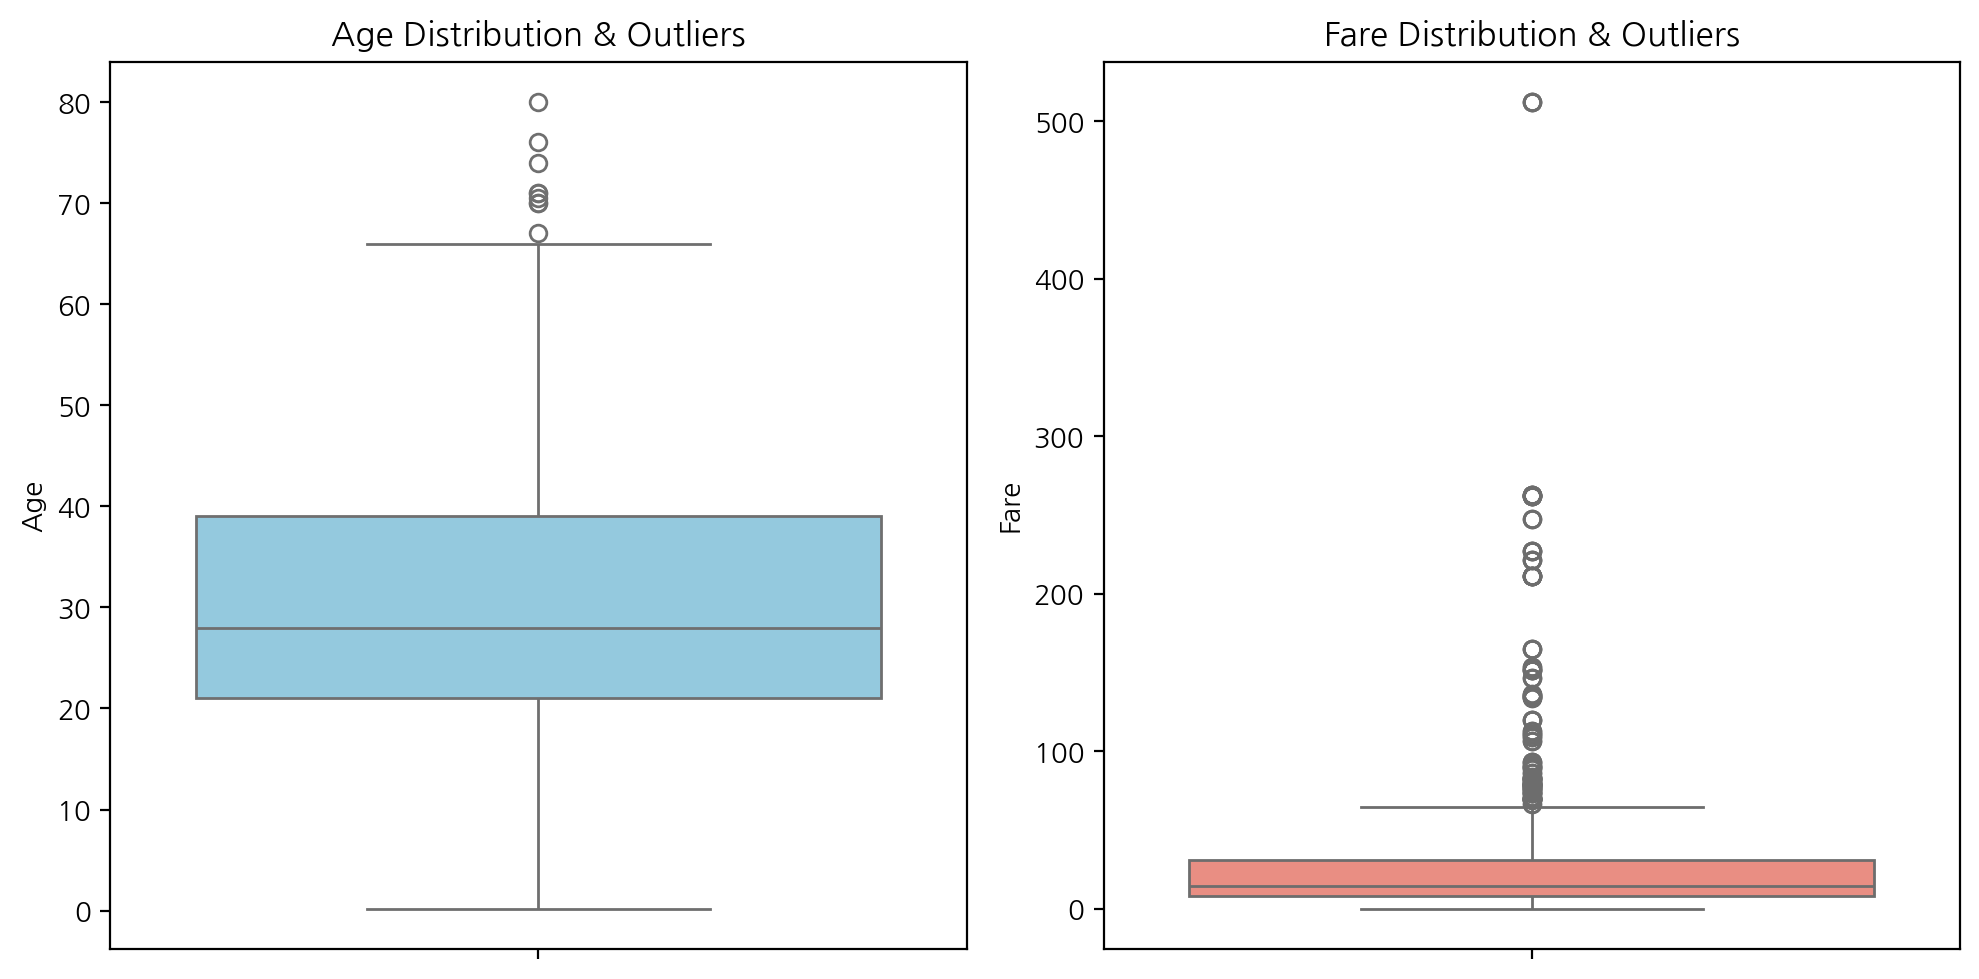

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1행 2열 구조로 아담하고 깔끔한 크기(10x5)의 서브플롯 생성
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# [1열] 나이(Age) 변수의 박스플롯
sns.boxplot(y='Age', data=tt, ax=axes[0], color='skyblue')
axes[0].set_title('Age Distribution & Outliers')
axes[0].set_ylabel('Age')

# [2열] 요금(Fare) 변수의 박스플롯
sns.boxplot(y='Fare', data=tt, ax=axes[1], color='salmon')
axes[1].set_title('Fare Distribution & Outliers')
axes[1].set_ylabel('Fare')

# 레이아웃 정돈 후 출력
plt.tight_layout()
plt.show()

In [ ]:
print(tt['Age'].mean())

29.881137667304014


In [ ]:
print(tt['Age'].min())

0.17


평균 나이가 낮아서 80대도 이상치로 발견된 것으로 판단함.

요금 데이터가 이상치가 많이 발견됨
3등급 객실의 사람이 많기 때문에 평균 금액이 낮아졌고, 0.00인 값이 존재(17개)하기 때문임을 파악함

In [ ]:
# Fare가 0인 행의 개수 구하기
zero_fare_count = (tt['Fare'] == 0).sum()

print("=== [데이터 확인] 요금(Fare)이 0원인 승객 수 ===")
print(f"총 {zero_fare_count}명")

=== [데이터 확인] 요금(Fare)이 0원인 승객 수 ===
총 17명


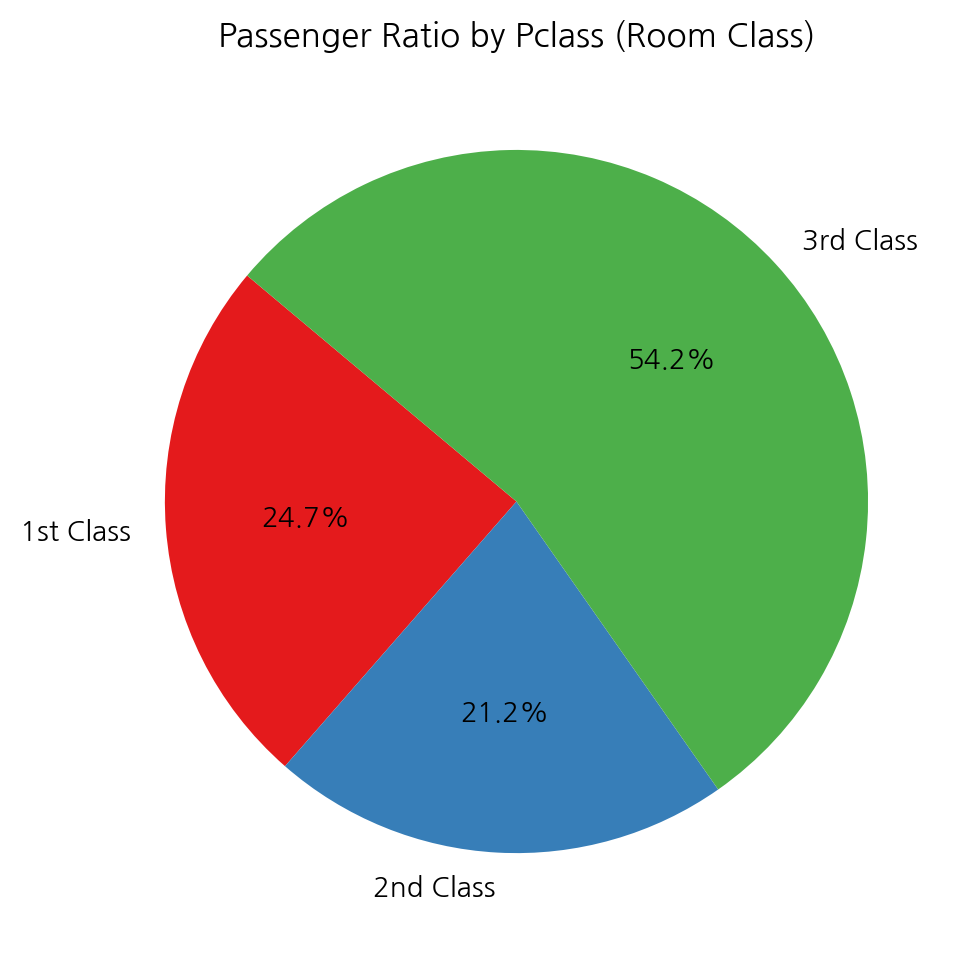

In [ ]:
import matplotlib.pyplot as plt

# 1. 데이터 가져오기 (각 객실 등급별 인원수)
pclass_counts = tt['Pclass'].value_counts().sort_index()

# 2. 아담하고 깔끔한 크기(5x5)로 그래프 생성
plt.figure(figsize=(5, 5))

# 3. 원형 그래프 그리기
# autopct='%1.1f%%'로 소수점 첫째 자리까지 비율 표시
# startangle=90으로 세로 축 기준 예쁘게 시작하도록 설정
plt.pie(
    pclass_counts,
    labels=['1st Class', '2nd Class', '3rd Class'],
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Set1.colors[:3]
)

# 그래프 제목 설정
plt.title('Passenger Ratio by Pclass (Room Class)')

# 출력 정돈
plt.tight_layout()
plt.show()

In [ ]:
print("[참고] 전체 객실 등급별 요금 평균 요약")
print(tt.groupby('Pclass')['Fare'].mean())

[참고] 전체 객실 등급별 요금 평균 요약
Pclass
1    87.508992
2    21.179196
3    13.302889
Name: Fare, dtype: float64


# 2.데이터 정제

## 2.1. 변수 특성별 결측치 처리 기준 수립

Embarked (탑승 장소) : 범주형 데이터

현황: 1309개 중 2개 누락 (결측치 비율 약 0.15%)

처리 방법: 최빈값 대체

탑승 장소는 문자형(범주형) 데이터이므로 평균을 낼 수 없음. 결측치가 단 2개로 매우 소수이기 때문에, 데이터셋에서 가장 압도적으로 많은 승객이 탑승한 장소인 최빈값 'S(Southampton)'로 채움.(약 70)

Fare (티켓 요금) : 연속형 숫자 데이터

현황: 1309개 중 1개 누락 (결측치 비율 약 0.07%) + 0.00값 17개 누락

처리 방법: 객실 등급의 중앙값(Median) 대체

극단적으로 비싼 티켓들이 존재하여 '평균'을 쓰면 수치가 왜곡될 수 있음. 따라서 대푯값으로 중앙값(Median)을 선택함. 또한, 객실 등급(1, 2, 3등실)에 따라 티켓 가격이 달라지므로 전체 중앙값으로 채우지 않고 객실 등급별로 세분화(Groupby)하여 빈칸을 채움.

Age (나이) : 연속형 숫자 데이터

현황: 1309개 중 263개 누락 (결측치 비율 약 20%)

처리 방법: 성별 및 객실 등급 평균 대체

성별'과 '자산 규모(객실 등급)'에 따라 탑승객의 연령대 분포가  달랐을 것이라 추정하여 결특치를 채움(예: 1등실에는 나이 든 부유층이, 3등실에는 젊은 노동자층이 많음).

Cabin (객실 번호) : 범주형/텍스트 데이터

현황: 1309개 중 1014개 누락 (결측치 비율 약 77.4%)

처리 방법: 결측치 자체를 하나의 새로운 범주('Unknown')로 지정

결측치 비율이 77%가 넘어가기 때문에 대체가 불가하다고 판단. 독립된 범주로 지정함.

## 2.2. 결측치 정제

### Fare 변수의 0값 null로 바꾸기

In [ ]:
import numpy as np

# Fare가 0인 값을 np.nan(Null)으로 일괄 치환
tt['Fare'] = tt['Fare'].replace(0, np.nan)

print("=== [치환 완료] 변환 후 Fare의 결측치(Null) 개수 ===")
print(tt['Fare'].isnull().sum())

=== [치환 완료] 변환 후 Fare의 결측치(Null) 개수 ===
18


In [ ]:
import pandas as pd

# 데이터 불러오기
tt = pd.read_csv('titanic1309.csv')

print("--- 처리 전 결측치 개수 ---")
print(tt.isnull().sum())

# 1. Embarked: 최빈값(S)으로 대체
most_frequent_embarked = tt['Embarked'].mode()[0]
tt['Embarked'] = tt['Embarked'].fillna(most_frequent_embarked)

# 2. Fare: 객실 등급(Pclass)별 요금의 중앙값으로 세분화해서 대체
tt['Fare'] = tt.groupby('Pclass')['Fare'].transform(lambda x: x.fillna(x.median()))

# 3. Age: 성별(Sex)과 객실 등급(Pclass)별 평균 나이로 세분화해서 대체
tt['Age'] = tt.groupby(['Sex', 'Pclass'])['Age'].transform(lambda x: x.fillna(x.mean()))

# 4. Cabin: 결측치가 너무 많으므로 'Unknown'이라는 새로운 범주로 채우기
tt['Cabin'] = tt['Cabin'].fillna('Unknown')

--- 처리 전 결측치 개수 ---
PassengerId       0
Survived          0
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64


In [ ]:
print("\n--- 처리 후 결측치 개수 ---")
print(tt.isnull().sum())


--- 처리 후 결측치 개수 ---
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


## 2.3. 변수 구간화

나이(Age)와 요금(Fare)을 unique로 확인한 결과 값의 종류가 매우 많음. 따라서 이를 연령대(Age_Bin: 어린이, 청소년, 청년 등)와 요금 구간(Fare_Bin: 저가, 중가, 고가 등)이라는 범주형 파생 변수로 가공하여 분석의 효율성과 가독성을 높임.

In [ ]:
print("나이")
print(tt['Age'].unique())

print("요금")
print(tt['Fare'].unique())

나이
[22.         38.         26.         35.         25.96226361 54.
  2.         27.         14.          4.         58.         20.
 39.         55.         30.81537975 31.         22.18532895 34.
 15.         28.          8.         19.         40.         37.03759398
 66.         42.         21.         18.          3.          7.
 49.         29.         65.         41.02927152 28.5         5.
 11.         45.         17.         32.         16.         25.
  0.83       30.         33.         23.         24.         46.
 59.         71.         37.         47.         14.5        70.5
 32.5        12.          9.         36.5        51.         55.5
 40.5        44.          1.         61.         56.         50.
 36.         45.5        20.5        62.         41.         52.
 63.         23.5        27.4992233   0.92       43.         60.
 10.         64.         13.         48.          0.75       53.
 57.         80.         70.         24.5         6.          0.67
 30.5     

In [ ]:
# 연속형 변수인 나이(Age)와 요금(Fare)을 분석하기 좋게 범주형 구간으로 쪼개기

# 1. 나이 구간화 (Age_Bin)
tt['Age_Bin'] = pd.cut(
    tt['Age'],
    bins=[0, 12, 19, 35, 60, 100],
    labels=['Child', 'Teenager', 'Young Adult', 'Adult', 'Elderly']
)

# 2. 요금 구간화 (Fare_Bin)
tt['Fare_Bin'] = pd.qcut(
    tt['Fare'],
    q=4,
    labels=['Low', 'Medium-Low', 'Medium-High', 'High']
)

In [ ]:
print(tt["Fare_Bin"])

0               Low
1              High
2        Medium-Low
3              High
4        Medium-Low
           ...     
1304     Medium-Low
1305           High
1306            Low
1307     Medium-Low
1308    Medium-High
Name: Fare_Bin, Length: 1309, dtype: category
Categories (4, object): ['Low' < 'Medium-Low' < 'Medium-High' < 'High']


# 3.분석

## 3.1. 전체 분석

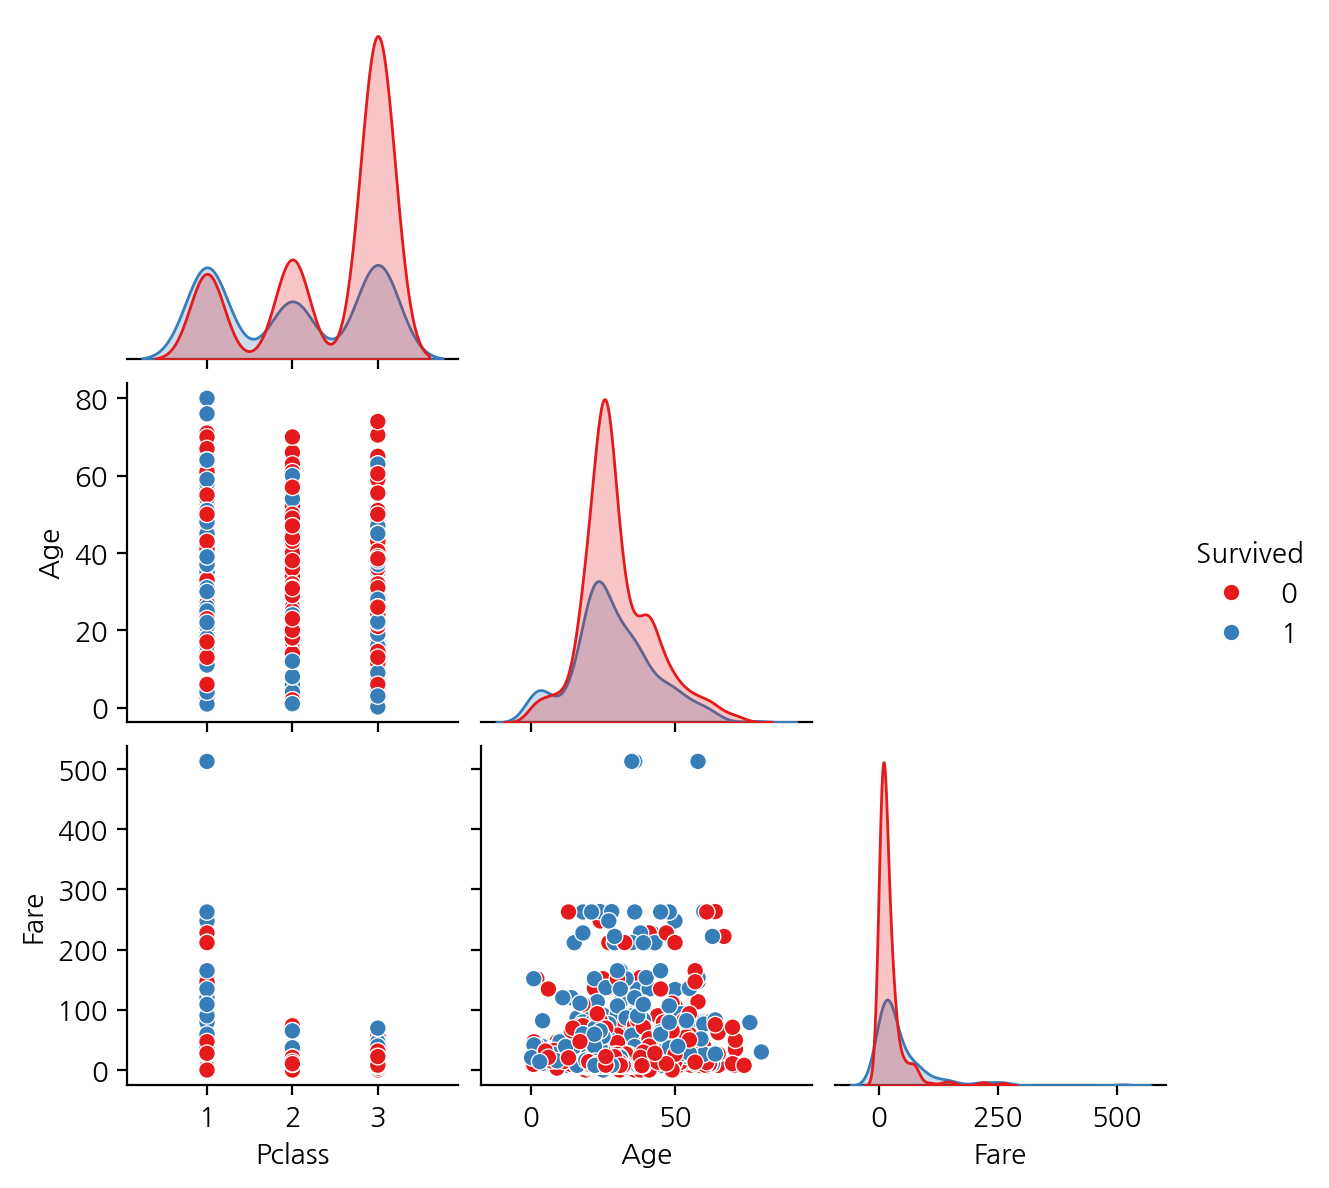

In [ ]:
# 분석에 핵심이 되는 숫자형 변수들만 딱 선택하기
core_features = ['Survived', 'Pclass', 'Age', 'Fare']


# corner=True를 주면 하단 삼각형만 남아서 아주 깔끔해짐
sns.pairplot(tt[core_features], hue='Survived', palette='Set1', height=2.0, corner=True)
plt.show()

Pclass (객실 등급) 분포: 1등실(1.0) 구간에서는 파란색(생존) 그래프가 주황색(사망)보다 확연히 높게 솟아있으나, 3등실(3.0) 구간에서는 주황색(사망) 승객의 밀도가 압도적으로 높음이 관찰됨.

Age (나이) 분포:  나이가 아주 어린 0~10세 초반(Child) 구간에서만 유일하게 파란색(생존) 밀도가 주황색을 역전하거나 대등한 수준을 보임. 이는 사회적 약자 보호 원칙이 반영된 결과임.

Fare (티켓 요금) 분포: 요금이 바닥에 깔려있는 저가 구간에는 주황색(사망) 점들이 극단적으로 밀집되어 있으나, 요금 축이 오른쪽(고가)으로 이동할수록 주황색 분포는 급격히 사라지고 파란색(생존) 분포만 길게 늘어지는 경향을 보임.

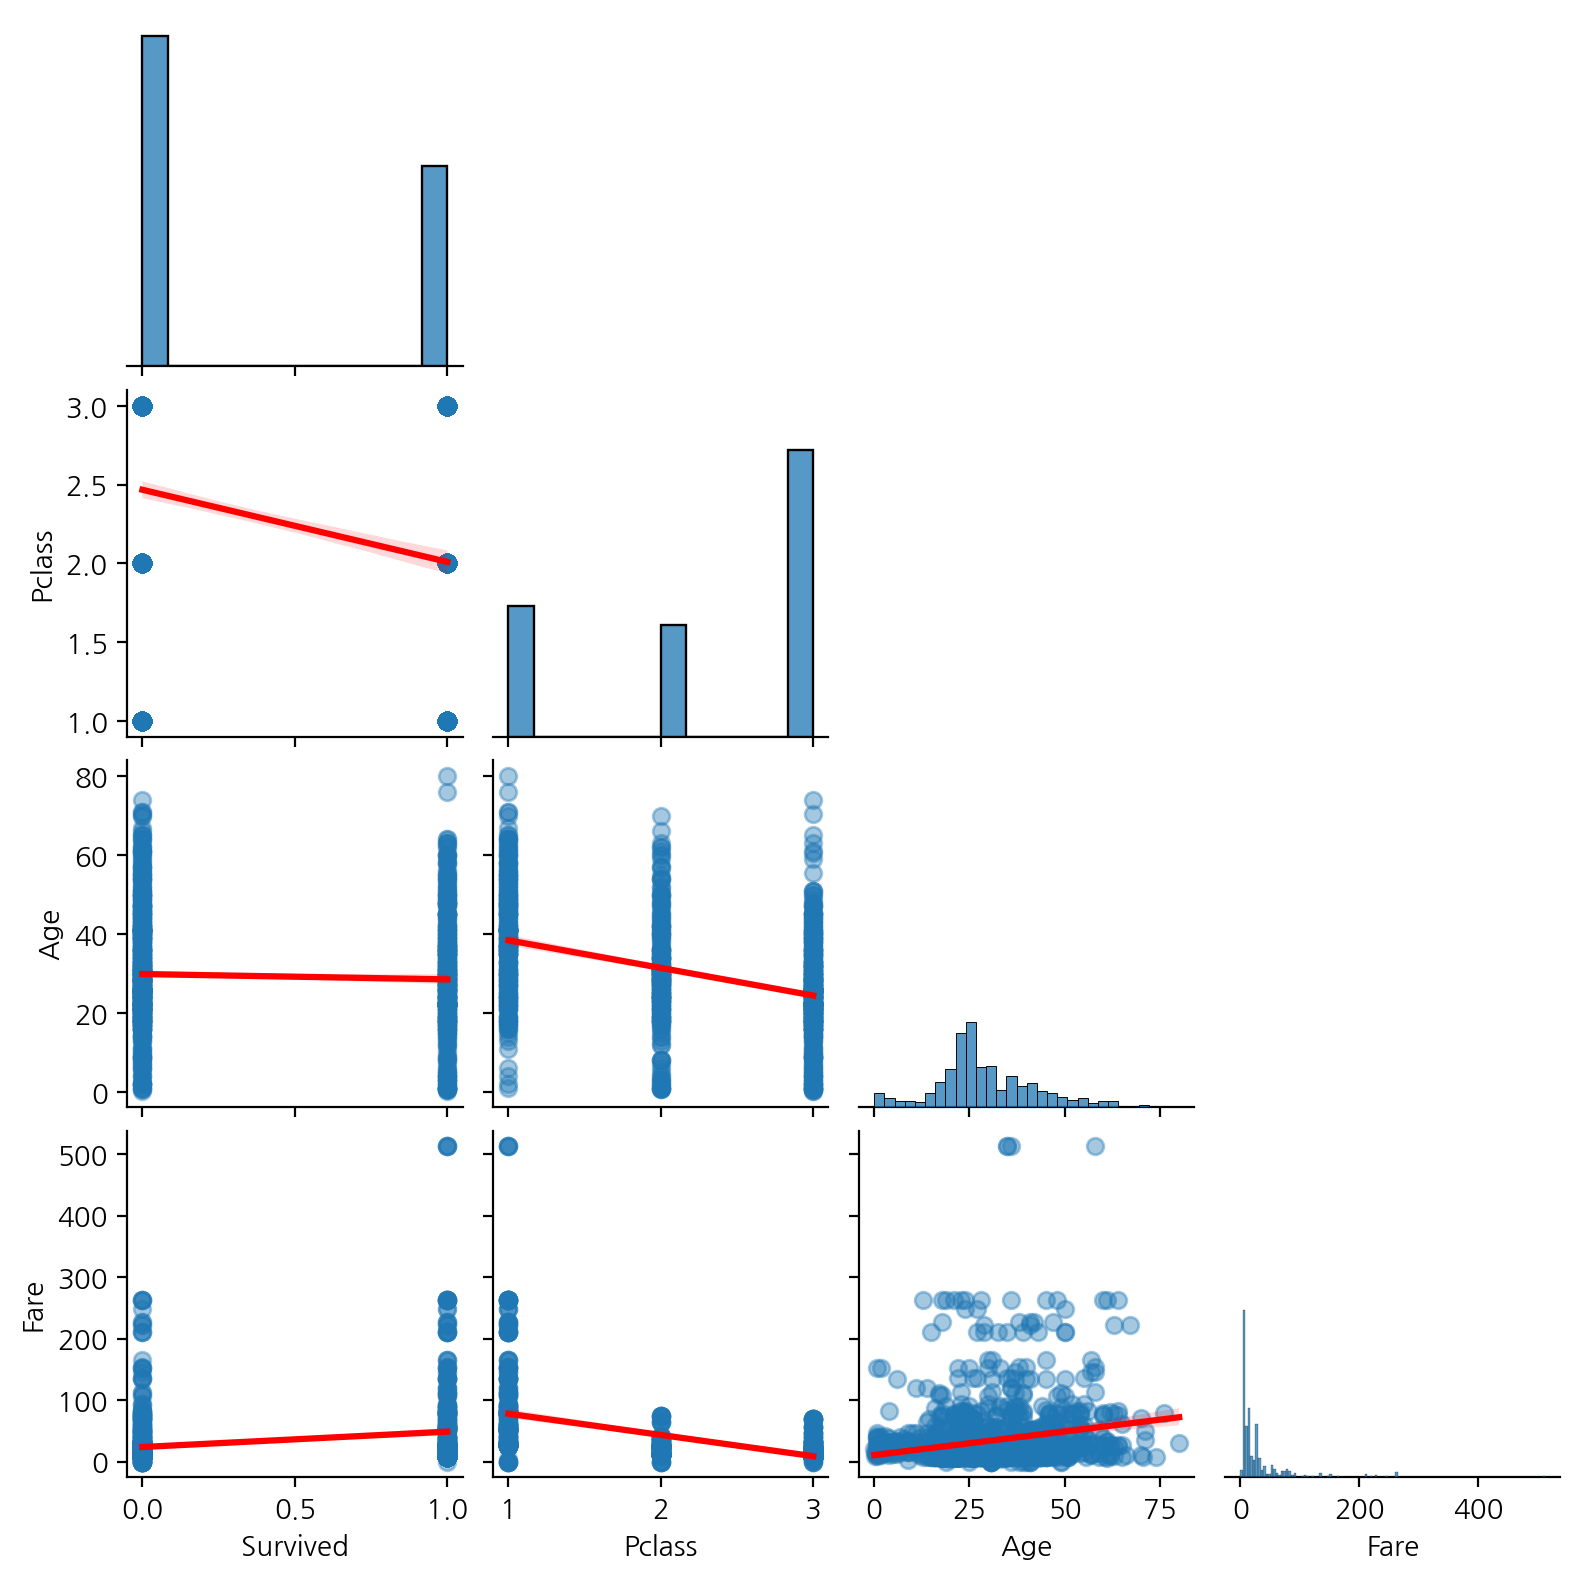

In [ ]:
# kind='reg'를 주면 산점도 위에 추세선이 그려짐
# (이때는 hue 옵션을 빼고 전체적인 변수 간 경향성을 보는 게 더 깔끔해)
sns.pairplot(tt[core_features], kind='reg', height=2.0, corner=True,
             plot_kws={'line_kws':{'color':'red'}, 'scatter_kws': {'alpha': 0.4}})
plt.show()

Survived × Pclass (우하향 $\searrow$):
객실 등급(Pclass)이 1등실에서 3등실(숫자가 커질수록)로 갈수록 생존율이 아래로 떨어지는 강력한 우하향 추세선이 관찰됨.등급 숫자가 커질수록(하층 계급일수록) 생존 확률이 선형적으로 급격히 감소했음을 직관적으로 증명함.

Survived × Age (완만한 우하향 $\searrow$ 또는 평행 $\rightarrow$):나이(Age)에 따른 추세선은 거의 평행에 가깝거나 아주 미세하게 우하향하는 흐름을 보임.이는 나이와 생존율 간의 단순 선형 관계는 그리 크지 않음을 뜻하며, 앞서 발견한 '영유아(Child) 구간의 피크 분포' 같은 비선형적 특성이 단순 직선 하나에는 온전히 담기지 못하는 통계적 한계를 보여줌.

Survived × Fare (우상향 $\nearrow$):요금(Fare)이 높아질수록 생존율이 위로 올라가는 양의 선형 추세선이 명확하게 나타남. 돈을 더 많이 지불한 승객일수록 생존이라는 결과에 긍정적인 영향을 받았음을 뜻함.

## 3.2. 단일 변수별 생존율 비교

각 변수 내부에서 생존율(Survived)에 미치는 단편적인 영향을 수치화하고 이를 시각화

생존율 계산이 불가능한 변수 4개 제외 (PassengerId(번호), Name(이름), Ticket(티켓번호), Cabin(객실 번호)

In [ ]:
import pandas as pd

print("=== [그룹 1] 범주형 및 숫자형 변수별 생존율 ===")

print("\n[Pclass별 생존율]")
print(tt.groupby('Pclass')['Survived'].mean())

print("\n[Sex별 생존율]")
print(tt.groupby('Sex')['Survived'].mean())

print("\n[Embarked별 생존율]")
print(tt.groupby('Embarked')['Survived'].mean())

print("\n[SibSp(형제/배우자)별 생존율]")
print(tt.groupby('SibSp')['Survived'].mean())

print("\n[Parch(부모/자녀)별 생존율]")
print(tt.groupby('Parch')['Survived'].mean())

print("\n[Age_Bin(연령대)별 생존율]")
print(tt.groupby('Age_Bin')['Survived'].mean())

print("\n[Fare_Bin(요금구간)별 생존율]")
print(tt.groupby('Fare_Bin')['Survived'].mean())

print("-" * 50)

# 2. 생존율 계산이 불가능한 고유 변수들 샘플 확인하기
print("=== [그룹 2] 고유 변수들 형태 확인 (평균 계산 불가능) ===")
print(tt[['PassengerId', 'Name', 'Ticket', 'Cabin']].head(3))

=== [그룹 1] 범주형 및 숫자형 변수별 생존율 ===

[Pclass별 생존율]
Pclass
1    0.575851
2    0.422383
3    0.269394
Name: Survived, dtype: float64

[Sex별 생존율]
Sex
female    0.82618
male      0.12930
Name: Survived, dtype: float64

[Embarked별 생존율]
Embarked
C    0.492593
Q    0.439024
S    0.335153
Name: Survived, dtype: float64

[SibSp(형제/배우자)별 생존율]
SibSp
0    0.334456
1    0.520376
2    0.452381
3    0.250000
4    0.181818
5    0.166667
8    0.111111
Name: Survived, dtype: float64

[Parch(부모/자녀)별 생존율]
Parch
0    0.331337
1    0.547059
2    0.530973
3    0.625000
4    0.333333
5    0.166667
6    0.000000
9    0.500000
Name: Survived, dtype: float64

[Age_Bin(연령대)별 생존율]
Age_Bin
Child          0.553191
Teenager       0.419847
Young Adult    0.341632
Adult          0.399390
Elderly        0.272727
Name: Survived, dtype: float64

[Fare_Bin(요금구간)별 생존율]
Fare_Bin
Low            0.219585
Medium-Low     0.292835
Medium-High    0.432927
High           0.569659
Name: Survived, dtype: float64
------------------------

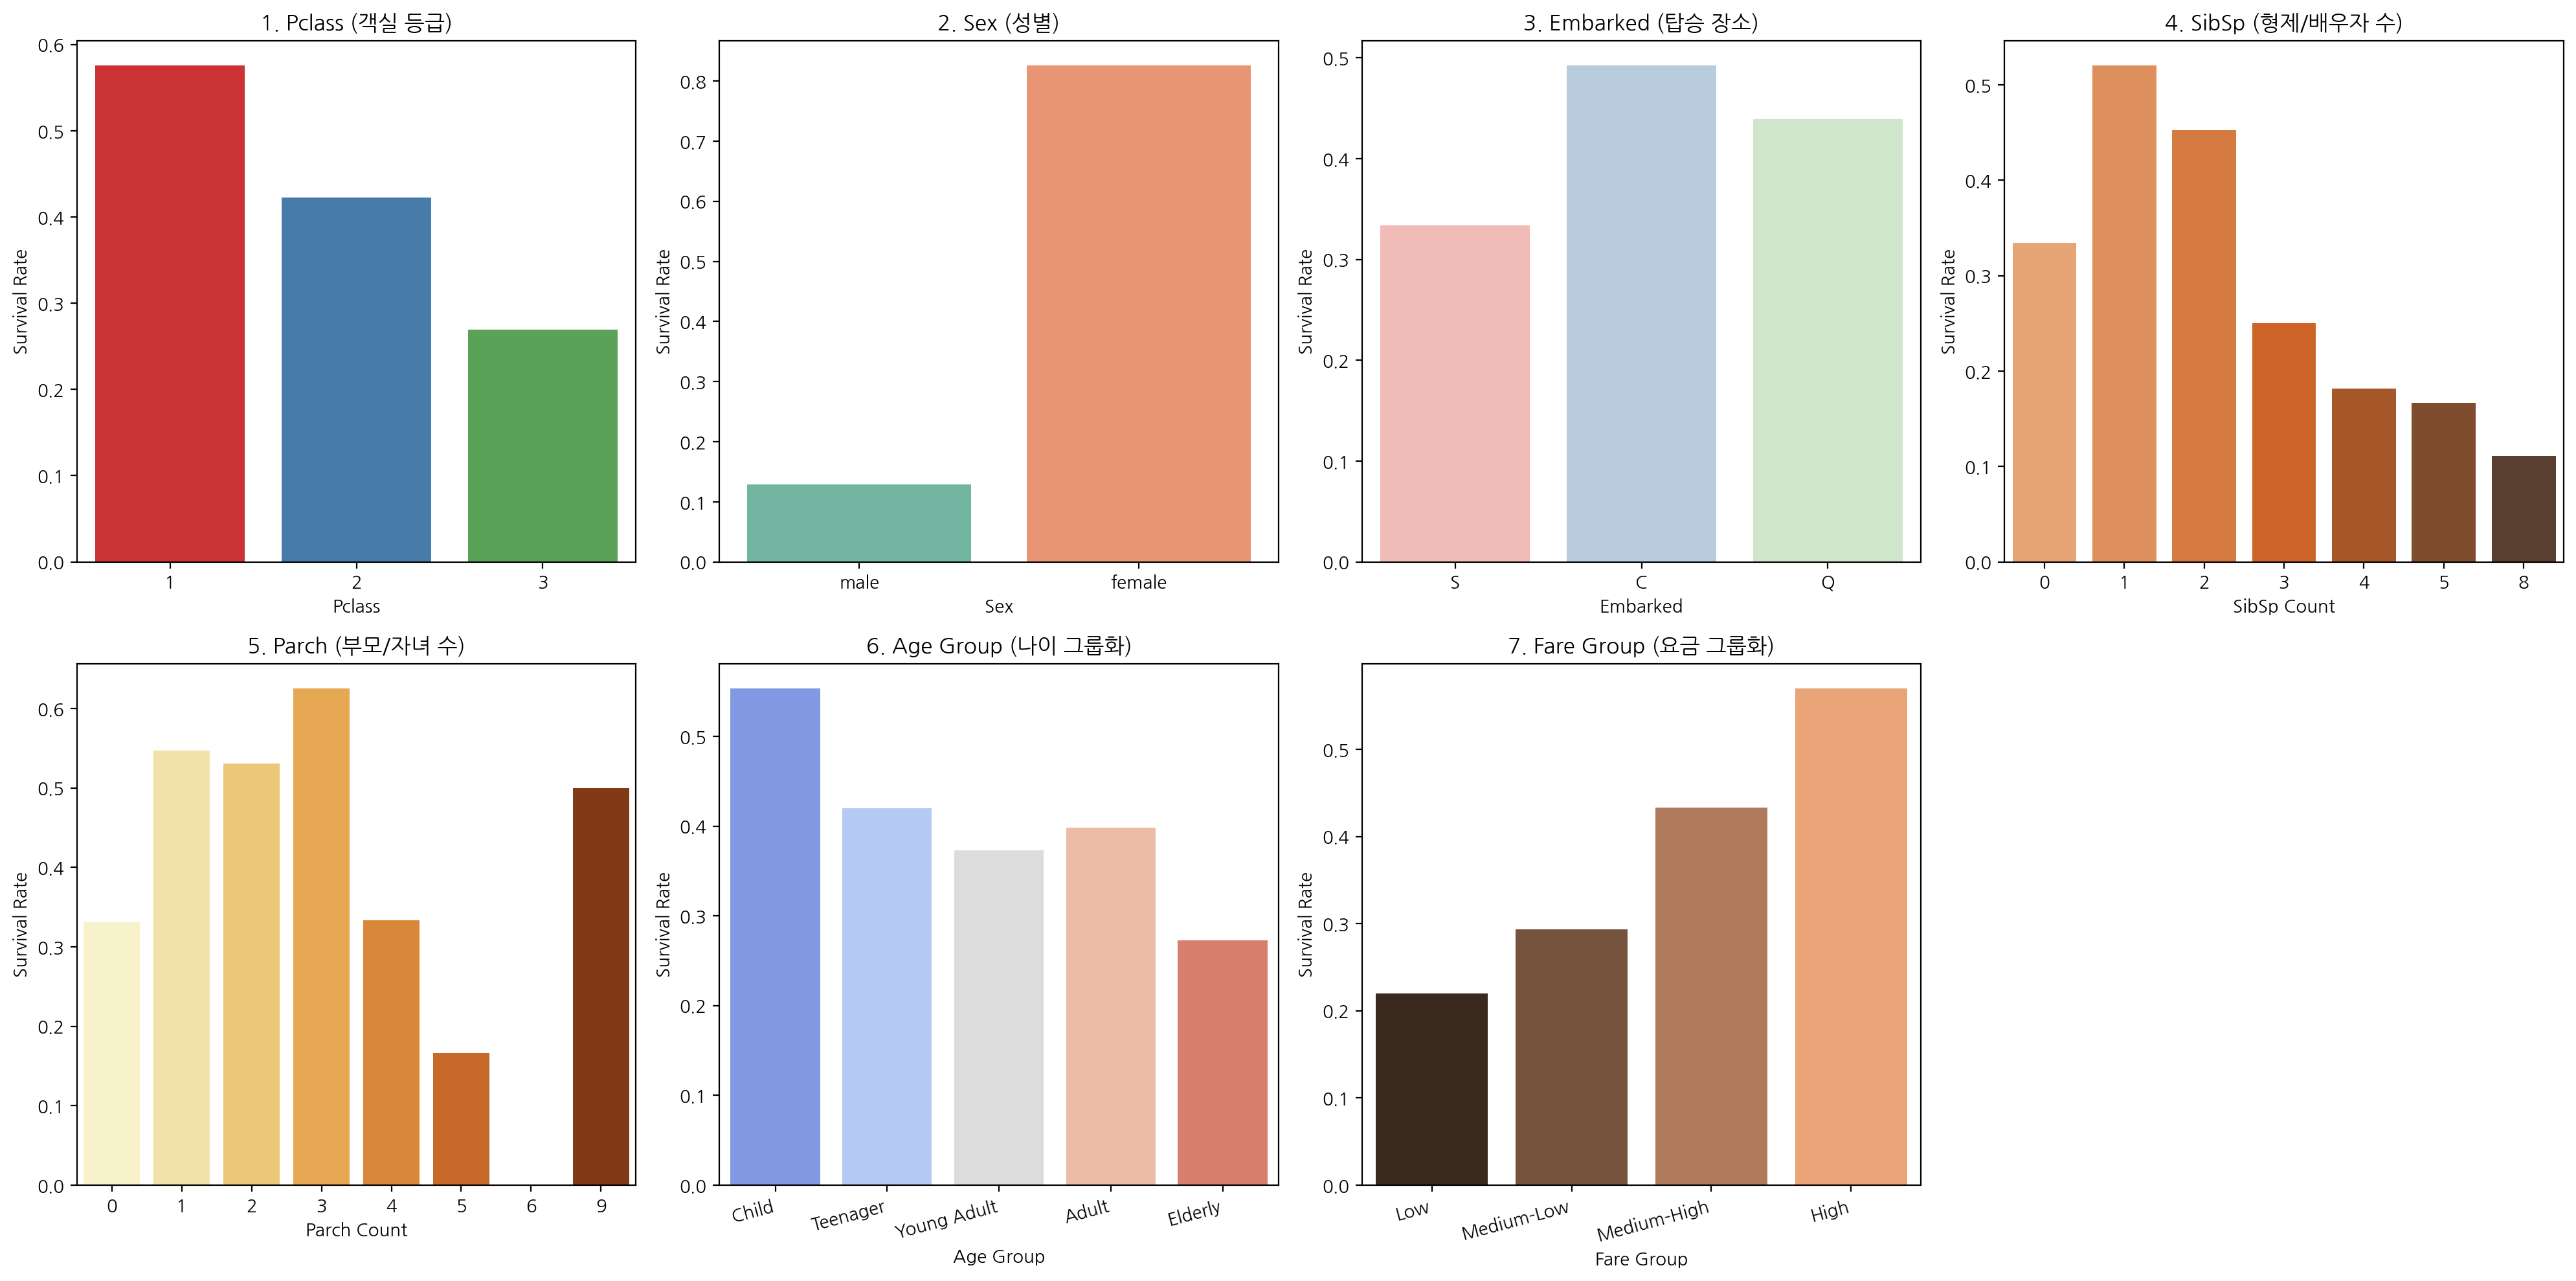

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 지저분한 경고 메시지 안 보이게 가리기
warnings.filterwarnings('ignore')

# 1. 데이터 안전하게 다시 불러오기
tt = pd.read_csv('titanic1309.csv')

# 2. 에러 방지를 위한 파생 변수(구간화) 생성
tt['Age_Bin'] = pd.cut(
    tt['Age'],
    bins=[0, 12, 19, 35, 60, 100],
    labels=['Child', 'Teenager', 'Young Adult', 'Adult', 'Elderly']
)

tt['Fare_Bin'] = pd.qcut(
    tt['Fare'],
    q=4,
    labels=['Low', 'Medium-Low', 'Medium-High', 'High']
)

# 2행 4열 구조의 액자 만들기 (20x10 크기)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# =========================================================================
# [1행] 각자 완전히 다른 색상으로 한눈에 구분되는 변수들 (1번 ~ 3번) + 4번
# =========================================================================

# [1행 1열] 객실 등급별 생존율 (파스텔톤의 완전히 다른 색상들)
sns.barplot(x='Pclass', y='Survived', data=tt, ax=axes[0, 0], palette='Set1', ci=None)
axes[0, 0].set_title('1. Pclass (객실 등급)')
axes[0, 0].set_xlabel('Pclass')
axes[0, 0].set_ylabel('Survival Rate')

# [1행 2열] 성별별 생존율 (남/여 확실히 다른 대비 색상)
sns.barplot(x='Sex', y='Survived', data=tt, ax=axes[0, 1], palette='Set2', ci=None)
axes[0, 1].set_title('2. Sex (성별)')
axes[0, 1].set_xlabel('Sex')
axes[0, 1].set_ylabel('Survival Rate')

# [1행 3열] 탑승 장소별 생존율 (S/C/Q 아예 다른 3색)
sns.barplot(x='Embarked', y='Survived', data=tt, ax=axes[0, 2], palette='Pastel1', ci=None)
axes[0, 2].set_title('3. Embarked (탑승 장소)')
axes[0, 2].set_xlabel('Embarked')
axes[0, 2].set_ylabel('Survival Rate')

# [1행 4열] 형제자매/배우자 수별 생존율 (오렌지 계열 명도 조절)
sns.barplot(x='SibSp', y='Survived', data=tt, ax=axes[0, 3], palette='Oranges_d', ci=None)
axes[0, 3].set_title('4. SibSp (형제/배우자 수)')
axes[0, 3].set_xlabel('SibSp Count')
axes[0, 3].set_ylabel('Survival Rate')


# =========================================================================
# [2행] 숫자의 크기에 따라 명도가 차례대로 조절되는 변수들 (5번 ~ 7번)
# =========================================================================

# [2행 1열] Parch(부모/자녀 수)별 생존율 (갈색/노란색 계열 명도 조절)
sns.barplot(x='Parch', y='Survived', data=tt, ax=axes[1, 0], palette='YlOrBr', ci=None)
axes[1, 0].set_title('5. Parch (부모/자녀 수)')
axes[1, 0].set_xlabel('Parch Count')
axes[1, 0].set_ylabel('Survival Rate')

# [2행 2열] Age_Bin(연령대)별 생존율 (파란색에서 빨간색으로 점진적 명도/수치 변화)
sns.barplot(x='Age_Bin', y='Survived', data=tt, ax=axes[1, 1], palette='coolwarm', ci=None,
            order=['Child', 'Teenager', 'Young Adult', 'Adult', 'Elderly'])
axes[1, 1].set_title('6. Age Group (나이 그룹화)')
axes[1, 1].set_xlabel('Age Group')
axes[1, 1].set_ylabel('Survival Rate')
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=15, ha='right')

# [2행 3열] Fare_Bin(요금 구간)별 생존율 (구리/갈색 계열 명도 조절)
sns.barplot(x='Fare_Bin', y='Survived', data=tt, ax=axes[1, 2], palette='copper', ci=None,
            order=['Low', 'Medium-Low', 'Medium-High', 'High'])
axes[1, 2].set_title('7. Fare Group (요금 그룹화)')
axes[1, 2].set_xlabel('Fare Group')
axes[1, 2].set_ylabel('Survival Rate')
axes[1, 2].set_xticklabels(axes[1, 2].get_xticklabels(), rotation=15, ha='right')

# [2행 4열] 마지막 빈 칸 숨기기
axes[1, 3].set_visible(False)


# 가로축 글자나 제목이 서로 겹치지 않게 여백 최적화
plt.tight_layout()
plt.show()

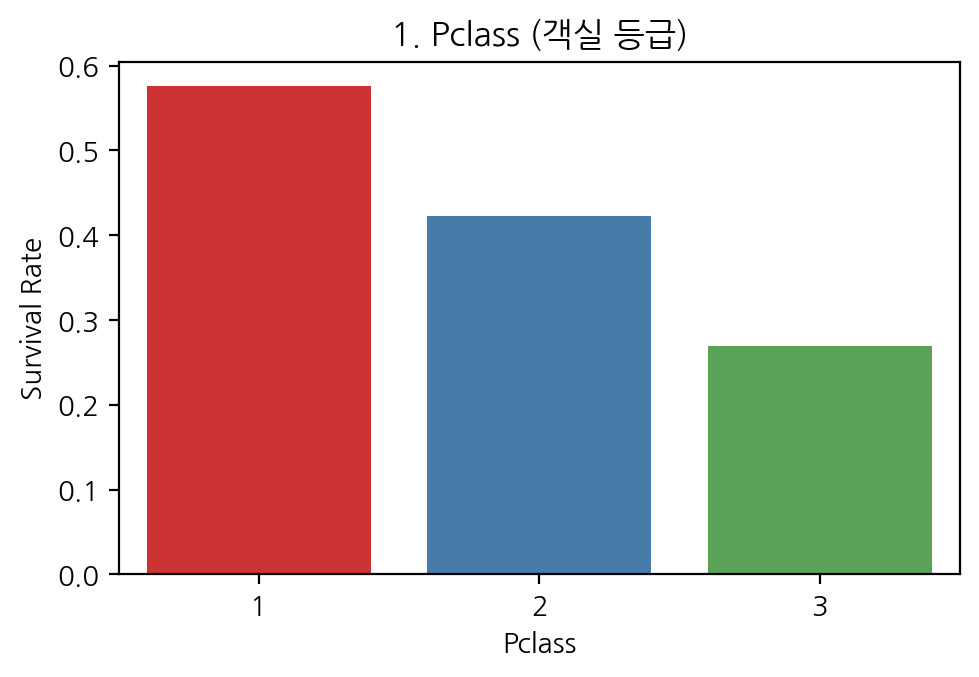

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 아담한 사이즈 설정
plt.figure(figsize=(5, 3.5))

# 1등급, 2등급, 3등급 각자 다른 색상 적용
sns.barplot(x='Pclass', y='Survived', data=tt, palette='Set1', ci=None)

plt.title('1. Pclass (객실 등급)')
plt.xlabel('Pclass')
plt.ylabel('Survival Rate')
plt.tight_layout()
plt.show()

Pclass (객실 등급)별 생존율 분석
분석 결과: 1등실(57.6%), 2등실(42.2%), 3등실(26.9%) 순으로 생존율이 높게 나타남.

객실 등급이 높을수록 생존율이 비례해서 상승함. 이는 높은 등급의 객실이 대피에 유리한 상층부에 위치하여,, 구조 과정에서 우선순위를 얻었기 때문이라고 판단됨

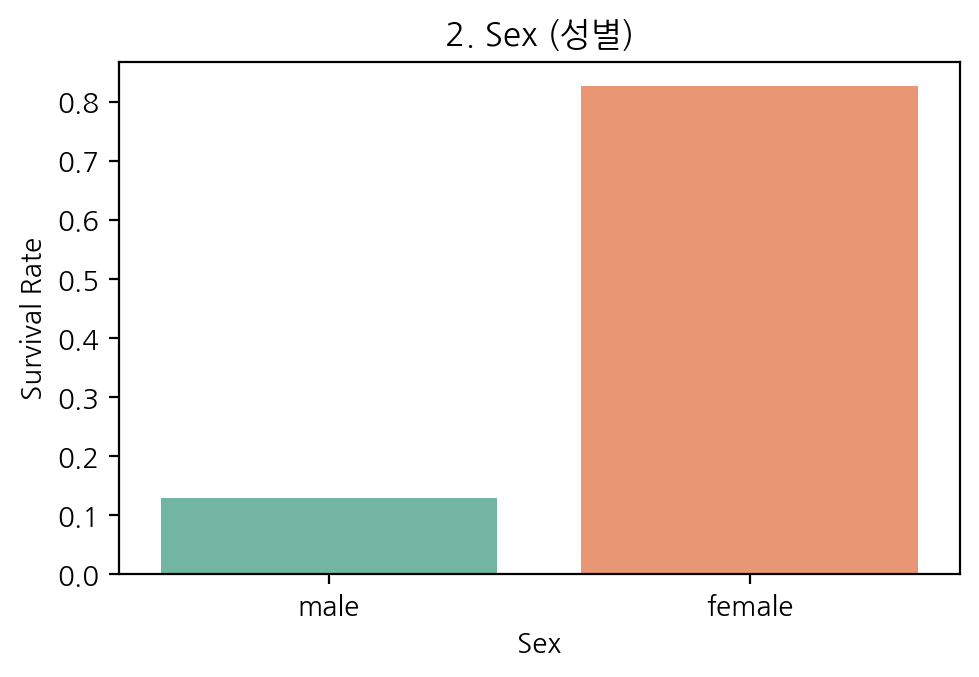

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 3.5))

# 남/여 확실히 다른 대비 색상 적용
sns.barplot(x='Sex', y='Survived', data=tt, palette='Set2', ci=None)

plt.title('2. Sex (성별)')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.tight_layout()
plt.show()

Sex (성별)별 생존율 분석
분석 결과: 여성 승객의 생존율은 약 82.6%로 압도적으로 높은 반면, 남성 승객의 생존율은 약 12.9%에 불과함.

당시 재난 상황에서 "여성과 아이를 먼저 구조한다"는 선박 대피 원칙이 매우 철저하게 지켜졌음을 보여주는 가장 명확한 증거임. 성별은 생존 여부를 가르는 가장 강력한 독립 변수 중 하나임.

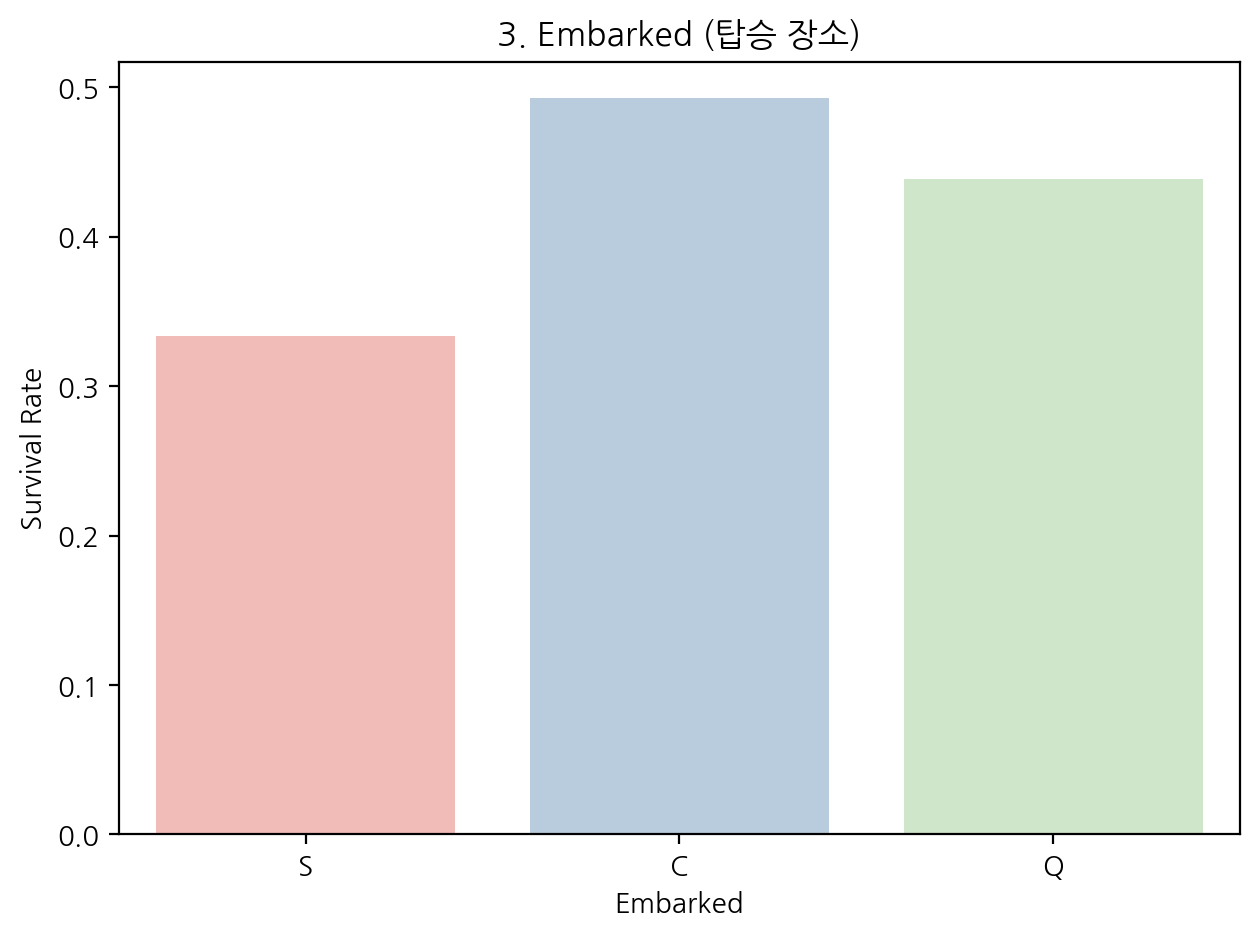

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 지저분한 경고 메시지 안 보이게 가리기
warnings.filterwarnings('ignore')
# S, C, Q 아예 다른 3색 적용
sns.barplot(x='Embarked', y='Survived', data=tt, palette='Pastel1', ci=None)

plt.title('3. Embarked (탑승 장소)')
plt.xlabel('Embarked')
plt.ylabel('Survival Rate')
plt.tight_layout()
plt.show()

Embarked (탑승 장소)별 생존율 분석
분석 결과: C (셰르부르) 탑승자의 생존율이 49.3%로 가장 높고, Q (퀸즈타운)가 43.9%, S (사우샘프턴)가 33.5%로 가장 낮음.

C(셰르부르) 탑승자들의 생존율이 가장 높았음을 확인 가능함. 이는 프랑스 부유층이 많이 탑승했던 C 지역 승객 중 높은 등급의 객실(1등실)을 예매한 비율이 높았기 때문으로 추정됨.

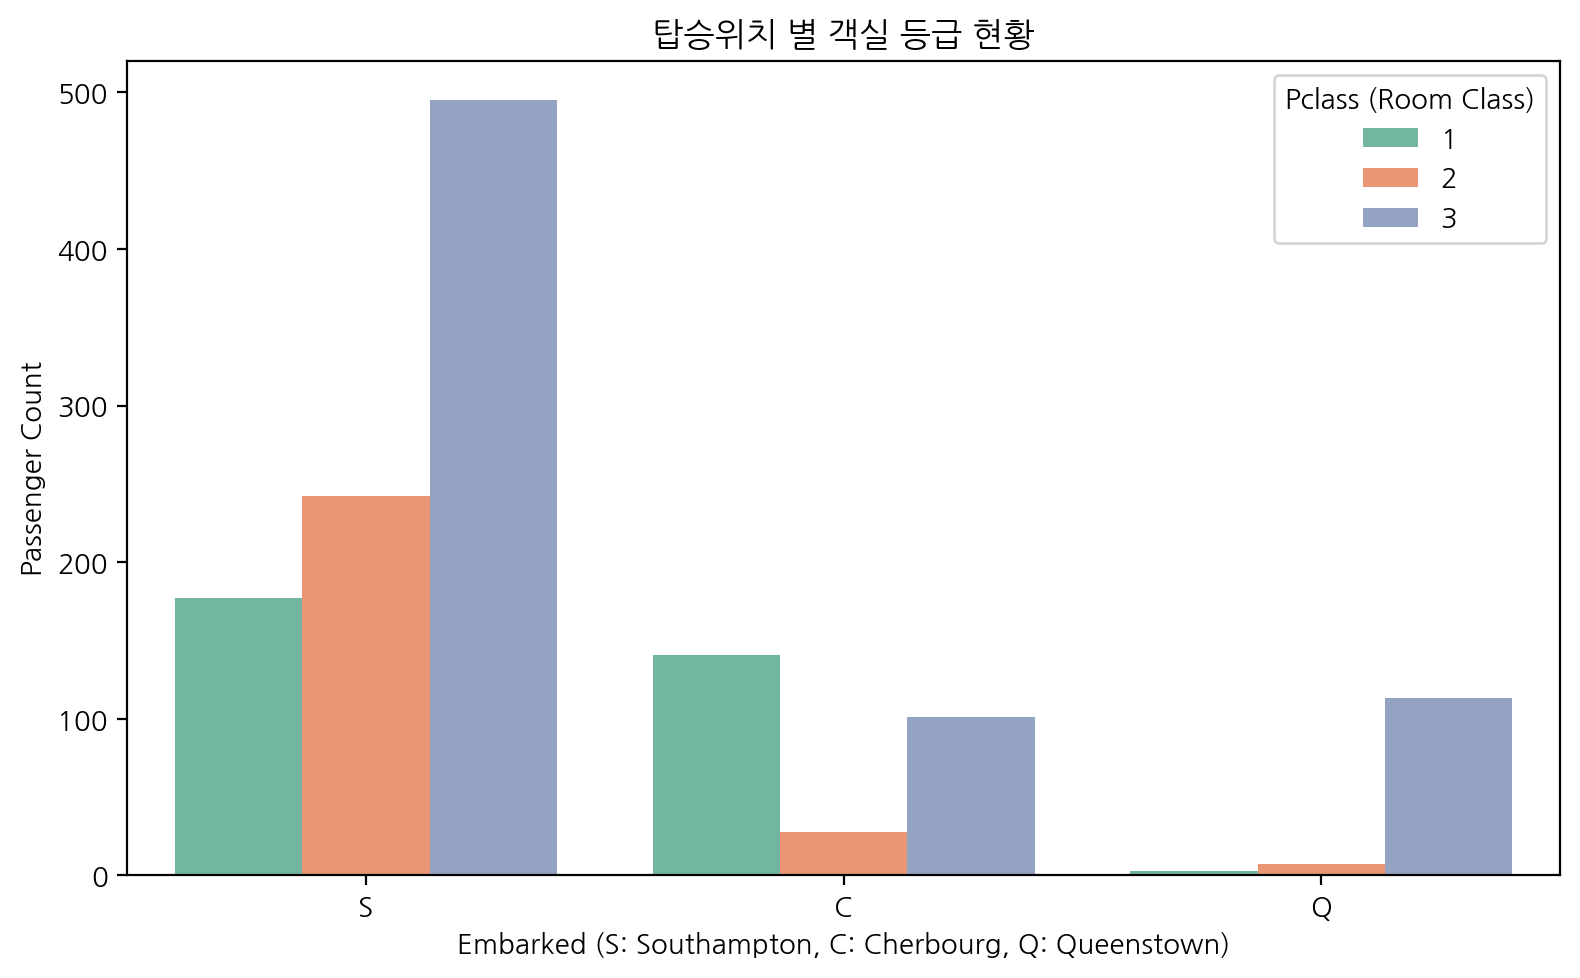

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

# 탑승 위치(Embarked)별로 객실 등급(Pclass) 승객 수를 카운트하여 시각화
# 1등실, 2등실, 3등실 비율을 색상(hue)으로 쪼개서 보여줌
sns.countplot(x='Embarked', hue='Pclass', data=tt, palette='Set2')

# 그래프 제목 및 레이블 설정
plt.title('탑승위치 별 객실 등급 현황')
plt.xlabel('Embarked (S: Southampton, C: Cherbourg, Q: Queenstown)')
plt.ylabel('Passenger Count')
plt.legend(title='Pclass (Room Class)')

# 출력
plt.tight_layout()
plt.show()

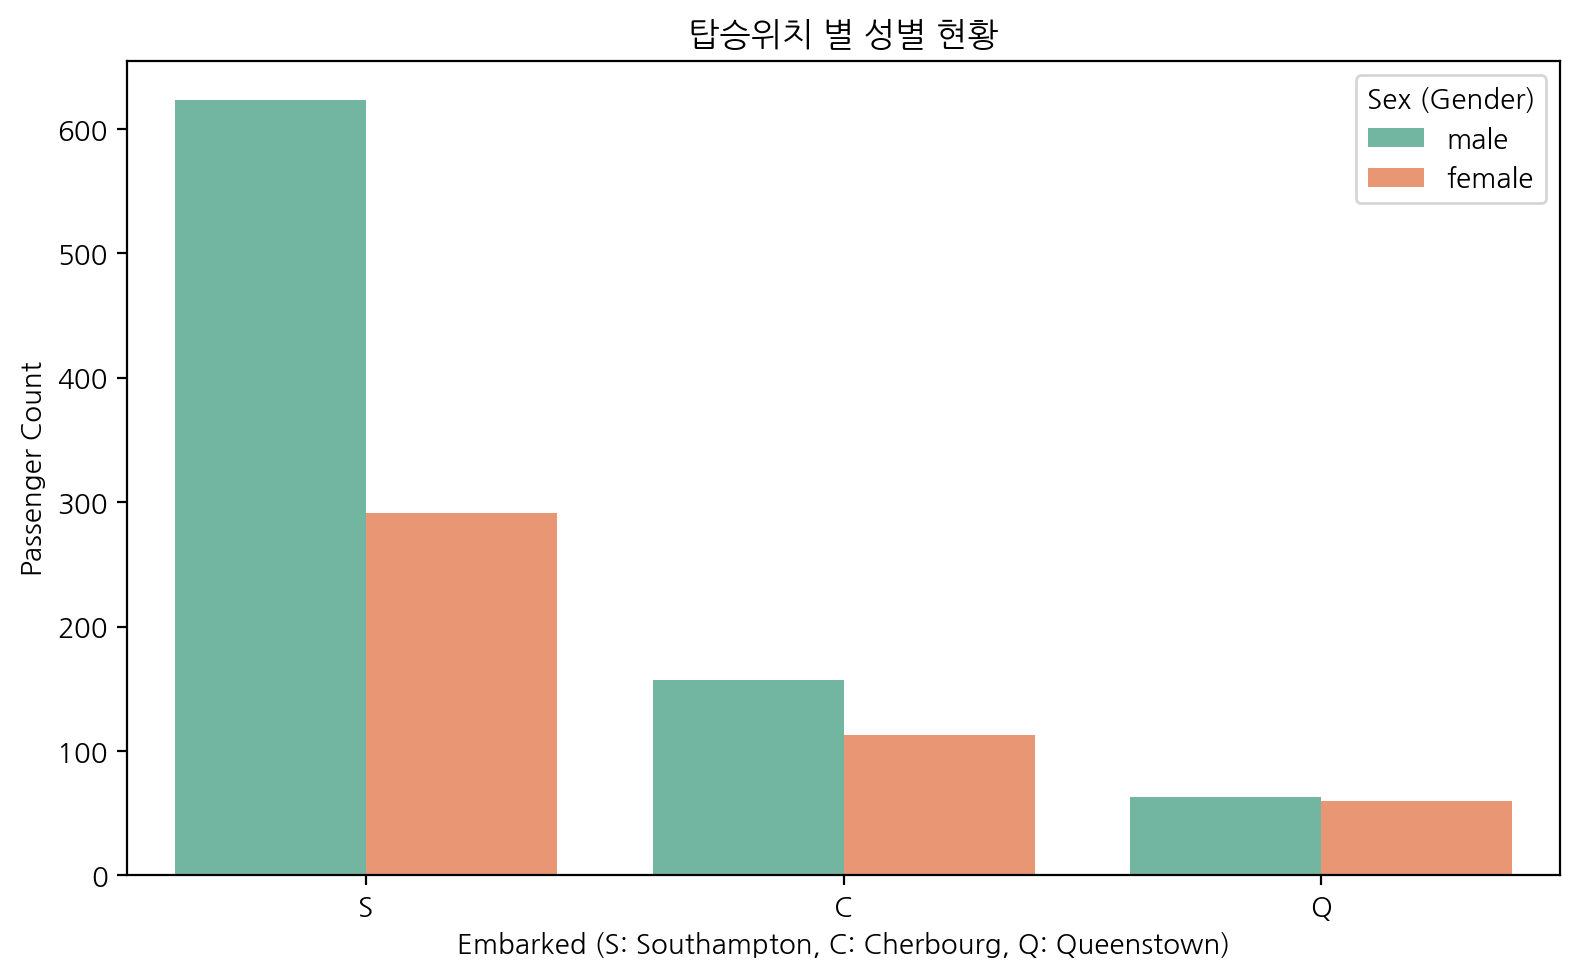

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

# hue를 'Sex'로 변경하여 탑승 위치별 남녀 승객 수를 시각화
sns.countplot(x='Embarked', hue='Sex', data=tt, palette='Set2')

# 그래프 제목 및 레이블 설정
plt.title('탑승위치 별 성별 현황')
plt.xlabel('Embarked (S: Southampton, C: Cherbourg, Q: Queenstown)')
plt.ylabel('Passenger Count')
plt.legend(title='Sex (Gender)')

# 출력
plt.tight_layout()
plt.show()

분석 결과, 생존율 순위(C,Q,S)에 따라 1등급 객실 비율이 높을 것이라고 추정한 가설이 틀림. 탑승 위치 별 성별 현황을 조회해보니 S 보다 Q가 여성의 비중이 높아 생존율이 높았음을 확인함.

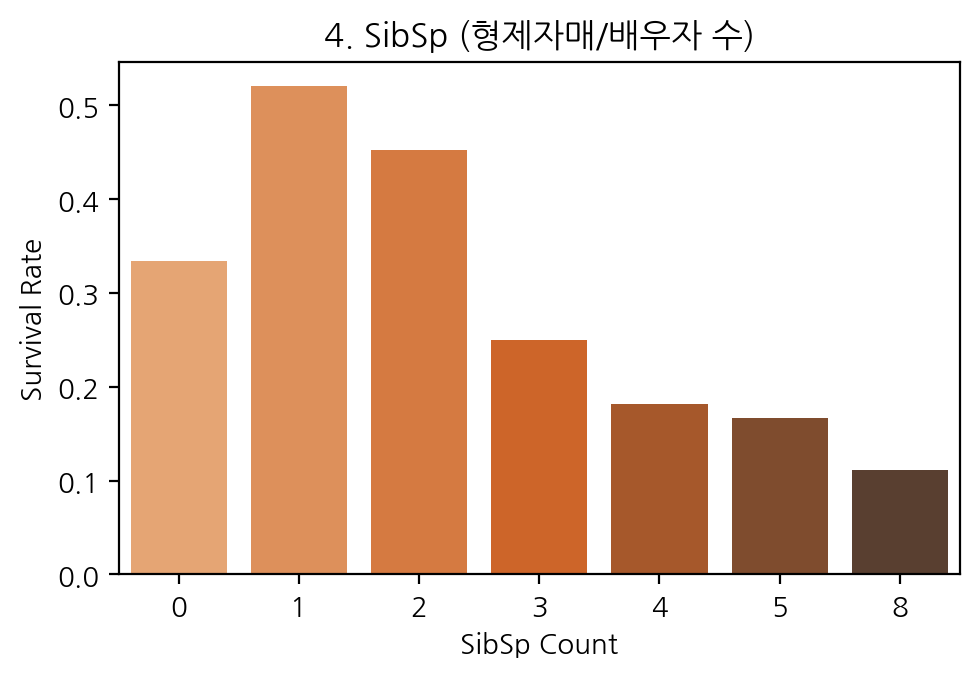

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 3.5))

# 오렌지 계열 명도 조절 스타일
sns.barplot(x='SibSp', y='Survived', data=tt, palette='Oranges_d', ci=None)

plt.title('4. SibSp (형제자매/배우자 수)')
plt.xlabel('SibSp Count')
plt.ylabel('Survival Rate')
plt.tight_layout()
plt.show()

SibSp (형제자매/배우자 수)별 생존율
분석 결과: 혼자 탄 사람(33.4%)보다 1명(52.0%) 또는 2명(45.2%)의 동반자가 있는 경우 생존율이 더 높음. 하지만 3명 이상(대가족)일 경우 생존율이 10~25%대로 급격히 떨어짐.

적당한 가족 동반은 구조 시 서로를 챙겨 생존에 도움이 되었으나, 가족 구성원이 너무 많으면 대피 지연이나 통제가 어려워 오히려 생존율이 낮아진 것으로 보임.

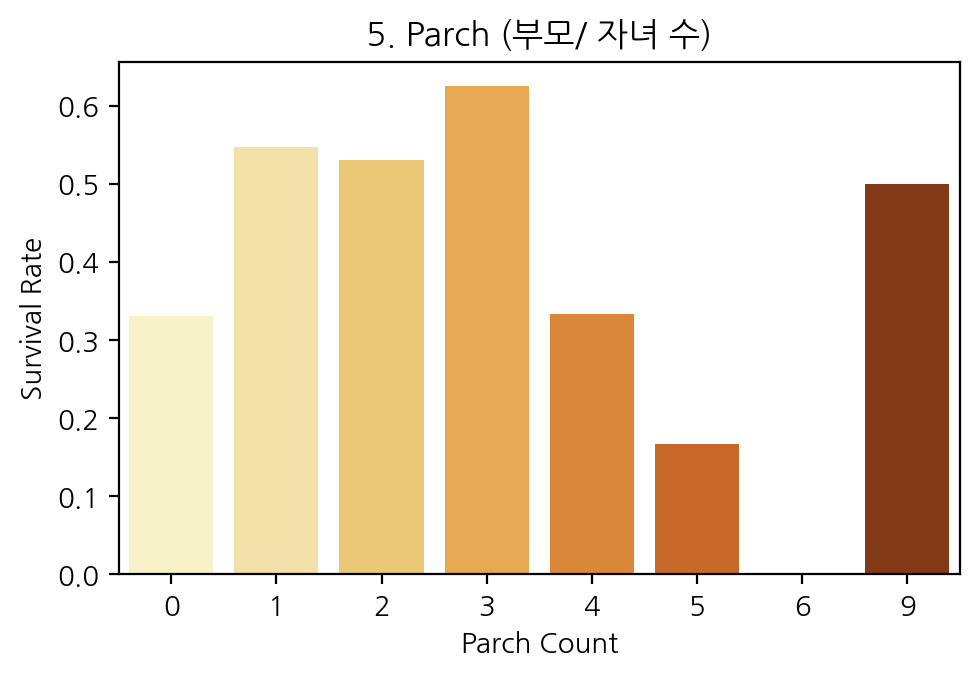

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 3.5))

# 갈색/노란색 계열 명도 조절 스타일
sns.barplot(x='Parch', y='Survived', data=tt, palette='YlOrBr', ci=None)

plt.title('5. Parch (부모/ 자녀 수)')
plt.xlabel('Parch Count')
plt.ylabel('Survival Rate')
plt.tight_layout()
plt.show()

In [ ]:
# Parch(부모/자녀 수)별로 실제 탑승객 수(Count)와 생존자 수의 평균(Mean)을 동시에 확인
parch_check = tt.groupby('Parch')['Survived'].agg(['count', 'mean'])

# 컬럼 이름 알아보기 쉽게 변경
parch_check.columns = ['실제 승객 수 (명)', '생존율 평균']
print("=== Parch 변수별 실제 승객 수 및 생존율 확인 ===")
print(parch_check)

=== Parch 변수별 실제 승객 수 및 생존율 확인 ===
       실제 승객 수 (명)    생존율 평균
Parch                       
0             1002  0.331337
1              170  0.547059
2              113  0.530973
3                8  0.625000
4                6  0.333333
5                6  0.166667
6                2  0.000000
9                2  0.500000


Parch (부모/자녀 수)별 생존율
분석 결과: 부모/자녀가 1~3명인 경우 생존율이 53% ~ 62.5%로 높은 편임. 반면, 혼자 탄 경우(33.1%)나 4명 이상인 대가족은 생존율이 떨어짐.


앞서 본 SibSp 변수와 마찬가지로, 재난 상황에서 가족이 적당히 있으면 구조에 서로 도움을 주었으나, 챙겨야 할 가족이 너무 많으면 대피가 지연되어 생존율이 낮아진 것으로 해석됨

Parch가 6명, 9명인구간에서 전체적인 대가족 생존율 하락 추세와 어긋나는 수치가 관찰됨. 데이터 확인 결과, 해당 구간은 실제 탑승객이 단 2명인 극소수 데이터였음, 표본 수 부족으로 발생한 통계적 착시로 판단함.


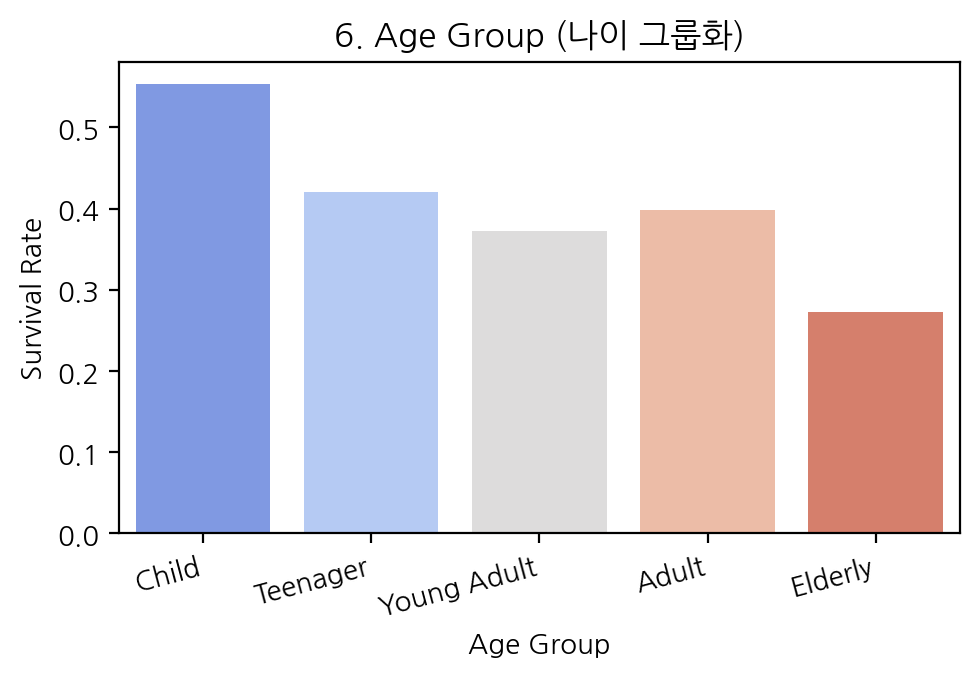

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 3.5))

# 파란색에서 빨간색으로 점진적으로 변하는 명도/톤 조절 스타일
sns.barplot(x='Age_Bin', y='Survived', data=tt, palette='coolwarm', ci=None,
            order=['Child', 'Teenager', 'Young Adult', 'Adult', 'Elderly'])

plt.title('6. Age Group (나이 그룹화)')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')

# 글자가 약간 기니까 겹치지 않게 15도만 회전
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

Age_Bin (연령대)별 생존율
분석 결과: 어린이(Child)의 생존율이 55.3%로 가장 높고, 노년층(Elderly)의 생존율이 27.3%로 가장 낮음. 10대~성인층은 34% ~ 41% 대의 생존율을 보임.

해석: 성별 분석과 일맥상통하게 "약자인 어린이와 여성을 먼저 구조한다"는 당시의 사회적 합의가 데이터로 증명됨. 체력적으로 대피가 어려웠을 노년층의 생존율이 가장 낮게 나타남.

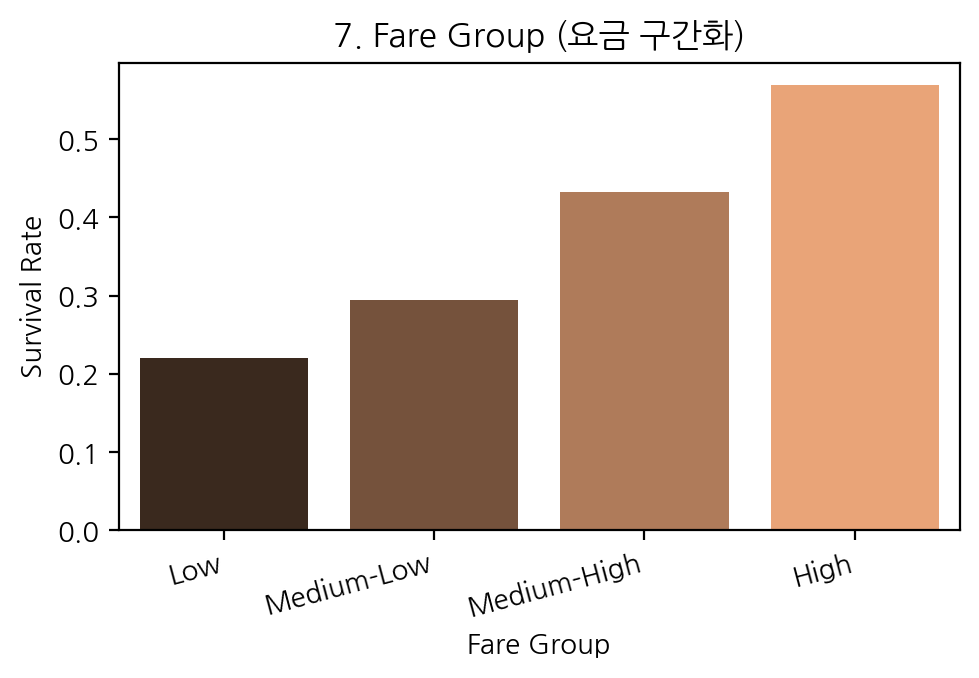

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 3.5))

# 구리/갈색 계열 명도 조절 스타일
sns.barplot(x='Fare_Bin', y='Survived', data=tt, palette='copper', ci=None,
            order=['Low', 'Medium-Low', 'Medium-High', 'High'])

plt.title('7. Fare Group (요금 구간화)')
plt.xlabel('Fare Group')
plt.ylabel('Survival Rate')

# 글자 겹침 방지 15도 회전
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

Fare_Bin (요금 구간)별 생존율
분석 결과: 요금이 가장 저렴한 구간(Low, 21.9%)에서 가장 비싼 구간(High, 56.9%)으로 갈수록 생존율이 계단식으로 완벽하게 상승함.

요금은 앞서 확인한 Pclass(객실 등급)와 매우 강한 상관관계를 가짐. 비싼 티켓을 산 승객들이 상층부의 좋은 객실을 배정받았고, 이것이 곧 생존율 상승으로 직결되었음을 보여주는 명확한 근거임.

## 3.3. 피어슨 상관계수 산출 및 히트맵

성별과 탑승 장소 같은 문자형 변수를 숫자로 인코딩한 후, 전체 핵심 변수 간의 피어슨 상관계수를 산출하여 격자형 히트맵으로 시각화.

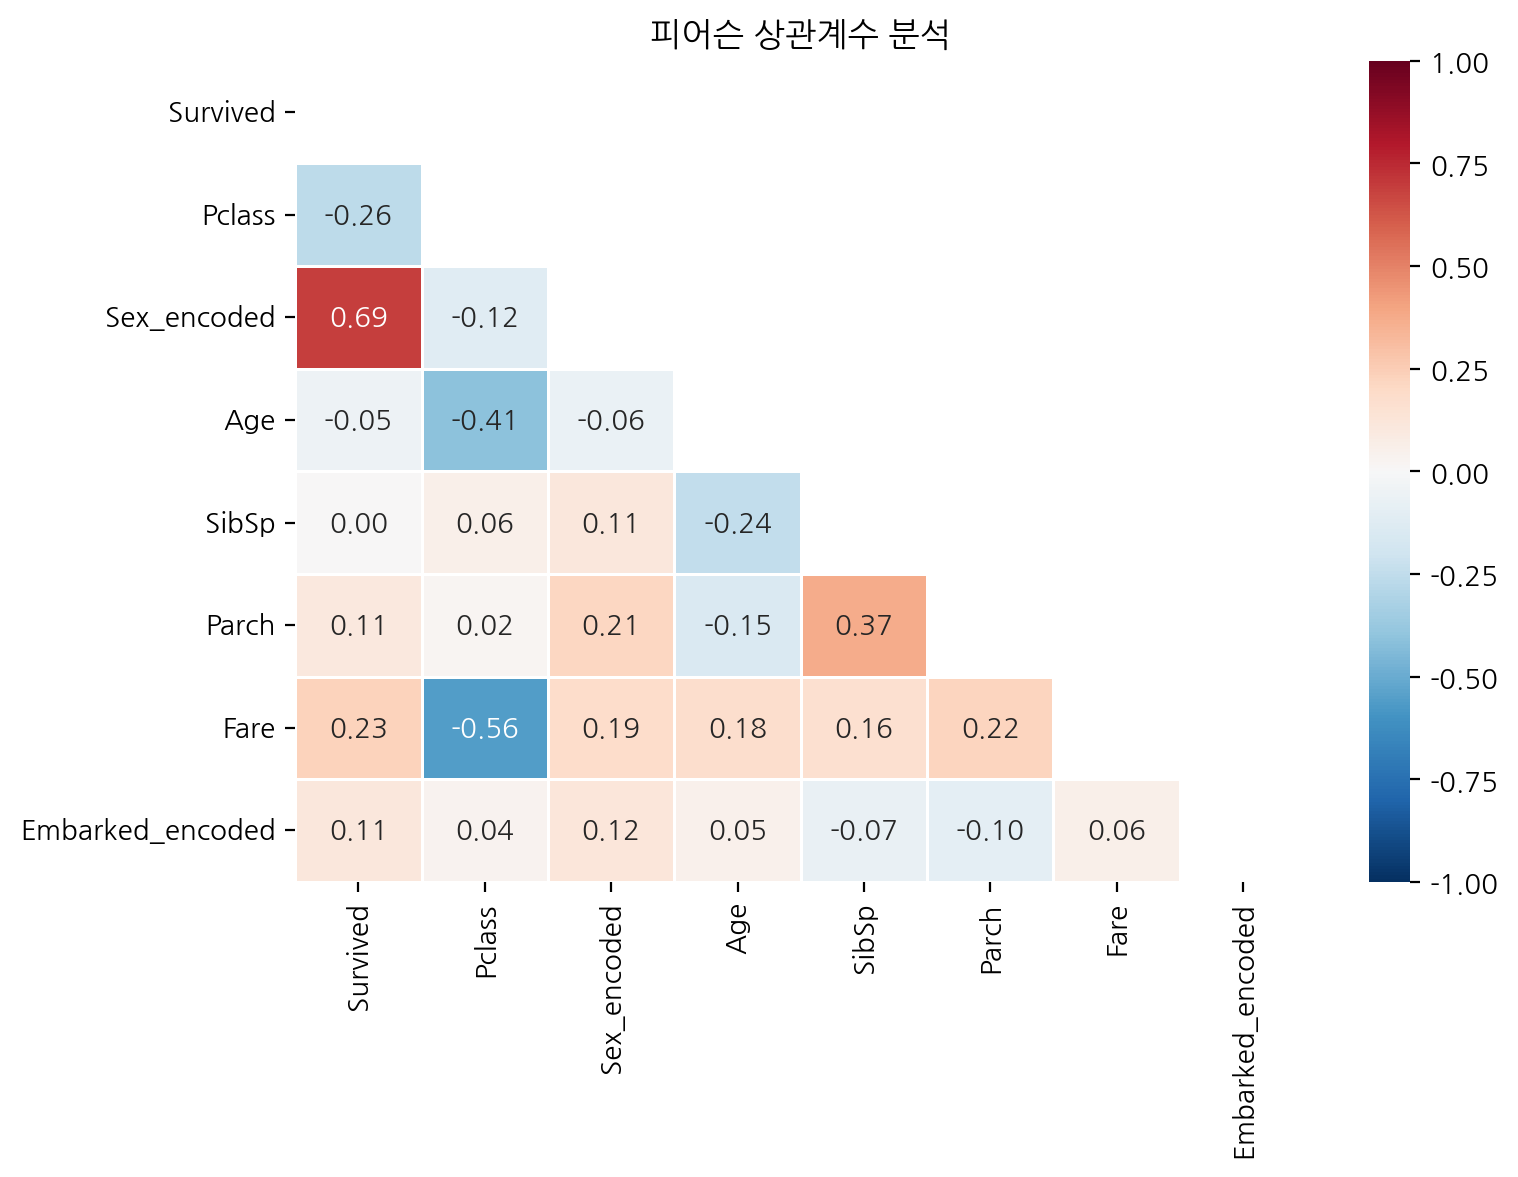

In [ ]:
import pandas as pd
import numpy as np  # 반으로 자르기 위해 넘파이 라이브러리 추가!
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 1. 경고 메시지 숨기기
warnings.filterwarnings('ignore')


# 3. 상관계수 계산을 위해 문자형 변수를 숫자로 변환
tt['Sex_encoded'] = tt['Sex'].map({'male': 0, 'female': 1})
tt['Embarked_encoded'] = tt['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# 4. 분석에 사용할 숫자형 변수들만 선택
corr_features = ['Survived', 'Pclass', 'Sex_encoded', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_encoded']
df_corr = tt[corr_features].corr()

mask = np.triu(np.ones_like(df_corr, dtype=bool))

# 5. 아담하고 한눈에 들어오는 크기(8x6)로 시각화
plt.figure(figsize=(8, 6))

# mask=mask 옵션을 추가해서 윗부분을 싹 지워줌
sns.heatmap(df_corr, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, fmt='.2f',
            linewidths=0.5, mask=mask)

# 그래프 제목 설정
plt.title('피어슨 상관계수 분석')

# 최종 출력
plt.tight_layout()
plt.show()

상관계수가 가진 선형성 측정의 한계로 변화가 뚜렷하지만 상관계수가 낮게 나오기도 함.

상관계수 행렬에서 가족 동반 수(SibSp)는 0.00으로 측정되어 생존과 아무런 관련이 없는 것처럼 보임. 하지만 앞선 3.1 절의 시각화 그래프와 groupby 수치를 보면 혼자 타거나 대가족일 땐 생존율이 낮고, 1~2명일 땐 생존율이 50% 위로 솟구치는 비선형($\cap$ 모양) 관계가 뚜렷함. 이는 상관계수의 통계적 한계 때문임.

Survived과의 상관계수 절대값이 0.1 이상인 변수 :

Sex_encoded (성별) 0.69 (양의 상관관계)

Pclass (객실 등급) (음의 상관관계)

Fare (티켓 요금) 0.23 (양의 상관관계)

Embarked_encoded (탑승 장소) 0.11 (양의 상관관계)

객실 등급과 나이, 요금이 음의 상관관계 / 형재자매,배우자수,부모,자녀수 가 양의 상관관계

# 4.분석 결과

## ① 사회적 약자 우선 구조 원칙의 증명

분석 결과: 상관계수 분석 결과, 생존율과 가장 강력한 양의 상관관계를 보인 변수는 성별(Sex_encoded, 0.69)로 나타났다. 또한 연령대별 분석에서도 어린이(Child)의 생존율이 55.3%로 가장 높았다.

인사이트: 이는 재난 상황에서 "여성과 아이를 먼저 구한다"는 당시의 사회적 합의와 대피 원칙이 데이터상으로 매우 엄격하고 완벽하게 작동했음을 증명한다.

## ② 객실 등급(Pclass)과 자본에 따른 생존율 격차


분석 결과: 객실 등급(Pclass)은 생존율과 -0.26의 음의 상관관계를 가졌으며, 티켓 요금(Fare)은 0.23의 양의 상관관계를 보였다. 또한 객실 등급과 요금 자체는 -0.56이라는 매우 강한 음의 상관관계를 나타냈다.

인사이트: 돈(Fare)을 많이 낼수록 상층부 객실(Pclass 1등실)을 배정받았고, 이는 구명보트가 있는 갑판으로의 물리적 접근성 및 구조 우선순위의 우위로 직결되었다.

탑승 장소(Embarked)와의 연관성: 예시로 살펴본 탑승 장소 분석에서 C(셰르부르) 지역 탑승자의 생존율(49.3%)이 가장 높았던 이유 역시, 해당 지역 탑승객 중 1등실 티켓을 구입한 부유층의 비율이 높았기 때문으로 해석된다. 결국 생존을 가른 본질적인 원인은 탑승 장소 자체가 아니라, 승객의 경제적 수준과 그에 따른 객실 등급이었다.

## ③ 인원 수에 따른 생존율

분석 결과:SibSp(형제/배우자 수), Parch(부모/자녀 수) 모두 생존율이 단순 선형적으로 움직이지 않고, 특정 임계점까지는 완만한 상승세를 보이다가 일정 인원수(4명 이상)를 넘어서는 시점부터 생존율이 급격히 붕괴하는 종 모양($\cap$)의 비선형 흐름을 공통적으로 나타냈다.

인사이트: 상호 구조 메커니즘과 시너지 효과: 동반 가족이 1~3명인 적정 규모의 상태에서는 재난 발생 시 서로를 챙기고 정보를 공유하며, 탈출 과정에서 심리적 안정감과 상호조력이라는 긍정적인 시너지로 작용하여 생존율을 극대화한 것으로 해석된다. 반면 완전히 혼자 탑승한 1인 승객(생존율 약 33%)은 고립된 상태에서 정보력과 구조 우선순위의 밀려 생존율이 상대적으로 저조했다.

동반 가족이 4명 이상인 과도한 대가족 구조에서는 오히려 생존율이 떨어졌다. 혼란스러운 선내 상황 속에서 노약자가 포함된 수많은 가족 구성원 전체를 한자리에 모으고 함께 이동하는 과정에서 동선 낭비와 대피 지연이 발생할 수밖에 없었으며, 전원이 함께 구명보트에 탑승하기 어려웠던 환경적 한계가 생존율의 급격한 하락으로 이어진 것으로 판단된다.

## ③ 최종 요약
결론적으로 타이타닉호의 생존율을 결정짓는 가장 핵심적인 요인은 **사회적 약자 보호 원칙**과 **객실 등급**(경제적 요인에 따른 구조적 유리함),**인원 수** 로 분석되었다.



# 5.인사이트 도출

## 5.1 3등급 탑승 고객이 살아남기 위한 전략

**전략 1: 혼자가 아닌 2~3인의 '적정 규모 동반자'를 구성하기**

단독 탑승(SibSp, Parch = 0)한 3등실 승객은 선내 지리에 어둡고 고립되어 사망률이 극대화되었다. 반면, 1~3명의 동반자가 있던 경우 생존율이 피크를 찍었다.

따라서 3등실 승객이 살기 위해서는 혼자 움직이는 각자도생을 버리고, 선내에서 마음이 맞는 동료나 가족 2~3인과 결성하여 정보를 공유하고 서로를 이끌어주는 상호 구조 메커니즘을 발동했어야 한다. (단, 4인 이상의 대가족은 이동 지연을 유발하므로 피해야 한다.)

**전략 2: Q(퀸즈타운) 지역 탑승객들의 대피 동선을 벤치마킹하기**

3등실 중에서도 S 지역 남성 중심의 서민층은 생존율이 바닥이었던 반면, 여성 비율이 높았던 Q 지역의 3등실은 대피 과정에서 '여성 우선 구조 원칙'의 흐름을 탈 기회가 더 많았다.

즉, 3등실 안에서도 무작정 남성 노동자 무리에 휩쓸려 다니기보다, 여성과 아이들이 먼저 모여 대피하는 동선(Q 지역 승객들의 이동 경로)에 밀착하여 구명보트가 있는 갑판으로의 접근권을 함께 확보하는 것이 생존 확률을 조금이라도 높이는 길이었다.

## 5.2 남성 승객이 살아남기 위한 전략

**전략 1: '가족 중심의 보호자' 포지션을 취하기**

타이타닉 데이터에서 아이(Child)나 부인(Parch, SibSp)을 동반한 가장 혹은 보호자 역할을 한 남성들은 구명보트 탑승 과정에서 가족을 보살핀다는 명분 하에 함께 탑승하거나, 여성 우선 구조의 낙수효과를 얻을 확률이 데이터상으로 더 존재했다.

따라서 각자도생하는 것보다, 사회적 약자(가족)를 부양하는 보호자로서 움직였어야 한다.

**전략 2: C(셰르부르) 지역의 '자본 권력' 흐름에 편승**

페어플롯과 추세선에서 보았듯, 남성 중 유일하게 생존의 불씨가 살아있던 집단은 1등실 초고가 티켓(Fare 200달러 이상)을 소지한 부유층 남성들이었다. 이들은 성별의 불리함을 '자본의 힘(갑판 우선 진입권 및 선사 혜택)'으로 생존율을 높였다.

만약 자본이 부족한 남성이라면, 대피 상황에서 1등실 부유층 승객들이 대거 탑승했던 C 지역 승객들의 동선을 파악하고, 그들이 자본의 힘으로 열어젖힌 '특별 대피 통로'를 물리적으로 추격해 탈출했어야 했다.

# 6.느낀점

분석을 진행하며 데이터 표면에 드러난 단순 수치나 단편적인 지표를 온전히 신뢰할 수 없고 입체적인 흐름을 파악하는 것이 중요하다고 느꼈다.

 가장 대표적으로 동반 가족 수(SibSp, Parch) 변수의 경우, 선형 상관계수는 0에 가깝게 측정되어 얼핏 생존율과 무관한 것처럼 보였다. 그러나 시각화를 수행해 본 결과, 혼자일 때보다 1~3명의 적정 가족을 동반했을 때 생존율이 정점을 찍고 대가족일 때 다시 추락하는 명확한 '비선형적 흐름'을 확인할 수 있었다.

더불어, Fare 변수의 박스플롯에서 발견한 많은 이상치가 데이터의 오류가 아닌 타이타닉호 내부의 빈부격차를 대변한다는 점과, 최고 생존율을 보인 C 지역이나은 예상한대로 1등급 고객이 많았지만, Q등급은 1등급 고객이 적었지만 여성이 많았기 때문에 생존율이 높았다.

왜곡 없는 인사이트를 도출하기 위해서는, 통계적 지표 산출에만 의존하지 않고 시각화와 변수 간 교차 검증 등 다방면의 데이터 분석을 수행해야 함을 배웠다. 이번 프로젝트는 데이터 분석을 하며 마주할 수많은 데이터셋을 어떤 태도로 바라보아야 하는지 이정표를 세워준 소중한 경험이었다.
